In [1]:
import numpy as np
import os

import sys
sys.path.append('/mnt/e/fyassine/ad-early-detection')
import config

from edges_utils_lib import run_network_analysis, run_diagnostic_tests
from import_utils import load_and_process_cohorts

In [2]:
cohorts = load_and_process_cohorts(config, correlation_type="pearson", remove_nan=True)
print('\n' + str(cohorts.keys()))

Healthy: 201 subjects, Matrix shape: (201, 110, 110), Edges shape: (201, 5995)
AD: 104 subjects, Matrix shape: (104, 110, 110), Edges shape: (104, 5995)
MCI: 533 subjects, Matrix shape: (533, 110, 110), Edges shape: (533, 5995)
Converters: 60 subjects, Matrix shape: (60, 110, 110), Edges shape: (60, 5995)

dict_keys(['healthy', 'ad', 'mci', 'converter'])


In [3]:
converters = cohorts['converter']
non_converters = cohorts['mci']

conv_edges, conv_ids = converters['edges'], converters['ids']
non_conv_edges, non_conv_ids = non_converters['edges'], non_converters['ids']

cohorts = {
    "converters": {
        "name": "Converters",
        "ids": conv_ids, 
        "edges": conv_edges
    },
    "non_converters": {
        "name": "Non Converters",
        "ids": non_conv_ids,
        "edges": non_conv_edges
    }
}

In [4]:
results = run_network_analysis(
    cohorts, 
    group_a="converters", 
    group_b="non_converters", 
    nbs_threshold=3.0, 
    n_perms=5000,
    run_permanova=True,
    run_nbs=True
)

In [5]:
diag_results = run_diagnostic_tests(cohorts, group_a="converters", group_b="non_converters", plot=False)

In [6]:
results

{'permanova': {'f_statistic': np.float64(1.529537997497547),
  'r_squared': np.float64(0.0025770208550328216),
  'p_value': np.float64(0.0033993201359728054),
  'n_permutations': 5000,
  'distance_metric': 'euclidean',
  'sample_size': 593,
  'num_groups': 2},
 'nbs': {'test_statistics': array([-0.80739739,  0.09314358, -0.59281014, ...,  0.75591476,
          1.16891665,  2.50392678], shape=(5995,)),
  'suprathreshold_edges': array([False, False, False, ..., False, False, False], shape=(5995,)),
  'all_components': [{'edges': array([ 221,  234,  238,  261,  276,  291,  301,  312,  358,  392,  539,
            548,  560,  565,  576,  679,  766,  821,  827,  850, 1066, 1094,
           1225, 1264, 1288, 1305, 1367, 1388, 1393, 1458, 1577, 1659, 1705,
           1742, 1940, 1971, 2001, 2073, 2347, 2437, 2492, 2802, 2931, 2942,
           2985, 3006, 3021, 3030, 3034, 3038, 3061, 3220, 3247, 3251, 3316,
           3317, 3321, 3331, 3441, 3449, 3469, 3477, 3484, 3503, 3700, 3811,
         

In [7]:
diag_results

{'valid': True,
 'pair_name': 'Converters vs Non Converters',
 'n_a': 60,
 'n_b': 533,
 'min_sample_size': 60,
 'avg_sd_a': np.float64(0.17679839384439308),
 'avg_sd_b': np.float64(0.17974425045281892),
 'sig_uncorrected': np.int64(600),
 'sig_fdr_count': np.int64(0),
 'sig_fdr_pct': np.float64(0.0),
 'median_effect_size': np.float64(0.11459454853116186),
 'pct_medium_effect': np.float64(0.21684737281067556),
 'pct_large_effect': np.float64(0.0),
 'pvals': array([0.60847677, 0.66518266, 0.65941794, ..., 0.33360658, 0.33320936,
        0.04455215], shape=(5995,)),
 'pvals_fdr': array([0.897814  , 0.91567625, 0.91356757, ..., 0.78196667, 0.78196667,
        0.48385893], shape=(5995,)),
 'cohens_d': array([-0.11328004,  0.0124489 , -0.08116933, ...,  0.10914616,
         0.15631995,  0.3006849 ], shape=(5995,))}

## Statistical Analysis Visualizations
### Converters vs Non-Converters Comparison

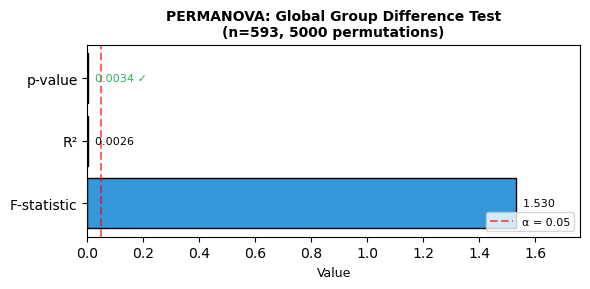

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 3))

permanova = results['permanova']
f_stat = permanova['f_statistic']
p_value = permanova['p_value']
r_squared = permanova['r_squared']
n_samples = permanova['sample_size']

permanova_sig = p_value < 0.05
result_color = '#27ae60' if permanova_sig else '#e74c3c'
result_symbol = '✓' if permanova_sig else '✗'

metrics = ['F-statistic', 'R²', 'p-value']
values = [f_stat, r_squared, p_value]
colors = ['#3498db', '#9b59b6', result_color]

bars = ax.barh(metrics, values, color=colors, edgecolor='black', linewidth=1)

ax.axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='α = 0.05')

ax.text(f_stat, 0, f'  {f_stat:.3f}', va='center', ha='left', fontsize=8)
ax.text(r_squared, 1, f'  {r_squared:.4f}', va='center', ha='left', fontsize=8)
ax.text(p_value, 2, f'  {p_value:.4f} {result_symbol}', va='center', ha='left', fontsize=8, color=result_color)

ax.set_xlabel('Value', fontsize=9)
ax.set_title(f'PERMANOVA: Global Group Difference Test\n(n={n_samples}, {permanova["n_permutations"]} permutations)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, max(values) * 1.15)

plt.tight_layout()
plt.show()

**Interpretation:** PERMANOVA tests whether the overall connectivity patterns differ between converters and non-converters. A significant p-value (< 0.05) indicates that the groups have different multivariate distributions. The R² value shows how much variance is explained by group membership.

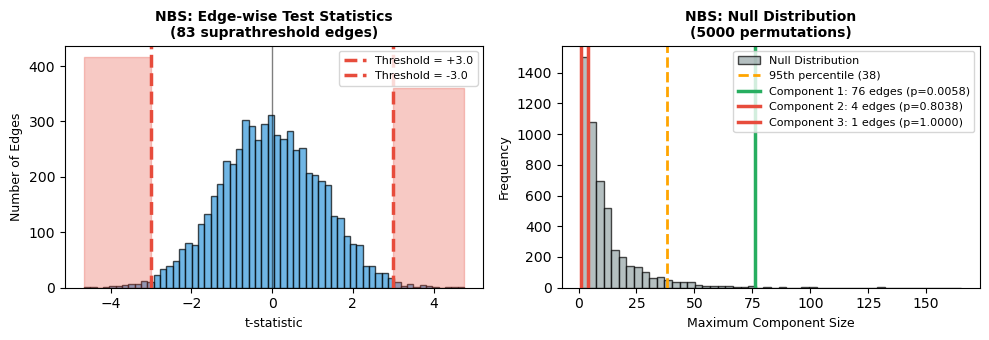

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

nbs = results['nbs']
test_stats = nbs['test_statistics']
threshold = nbs['primary_threshold']

axes[0].hist(test_stats, bins=60, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(threshold, color='#e74c3c', linestyle='--', linewidth=2.5, label=f'Threshold = +{threshold}')
axes[0].axvline(-threshold, color='#e74c3c', linestyle='--', linewidth=2.5, label=f'Threshold = -{threshold}')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

n_supra = np.sum(np.abs(test_stats) > threshold)
axes[0].fill_betweenx([0, axes[0].get_ylim()[1]*1.1], threshold, test_stats.max(), alpha=0.3, color='#e74c3c')
axes[0].fill_betweenx([0, axes[0].get_ylim()[1]*1.1], test_stats.min(), -threshold, alpha=0.3, color='#e74c3c')

axes[0].set_xlabel('t-statistic', fontsize=9)
axes[0].set_ylabel('Number of Edges', fontsize=9)
axes[0].set_title(f'NBS: Edge-wise Test Statistics\n({n_supra} suprathreshold edges)', fontsize=10, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)

null_dist = nbs['null_distribution']
components = nbs['all_components']

axes[1].hist(null_dist, bins=50, color='#95a5a6', edgecolor='black', alpha=0.7, label='Null Distribution')
pct_95 = np.percentile(null_dist, 95)
axes[1].axvline(pct_95, color='orange', linestyle='--', linewidth=2, label=f'95th percentile ({pct_95:.0f})')

for i, comp in enumerate(components[:3]):
    is_sig = comp.get('significant', False)
    color = '#27ae60' if is_sig else '#e74c3c'
    label = f"Component {i+1}: {comp['size']} edges (p={comp.get('p_value', 1):.4f})"
    axes[1].axvline(comp['size'], color=color, linestyle='-', linewidth=2.5, label=label)

axes[1].set_xlabel('Maximum Component Size', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=9)
axes[1].set_title(f'NBS: Null Distribution\n({nbs["n_permutations"]} permutations)', fontsize=10, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

**Interpretation:** Network-Based Statistic (NBS) identifies connected components of edges that show group differences. The left plot shows the distribution of t-statistics for all edges, with red areas indicating suprathreshold edges. The right plot compares observed component sizes to the null distribution. Only components larger than expected by chance (above the orange line) are significant.

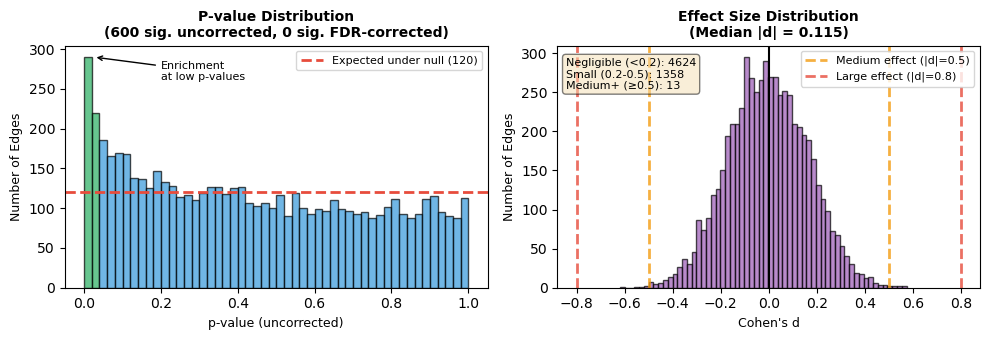

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

pvals = diag_results['pvals']
n_edges = len(pvals)

n_bins = 50
n, bins, patches = axes[0].hist(pvals, bins=n_bins, color='#3498db', edgecolor='black', alpha=0.7)
expected_per_bin = n_edges / n_bins
axes[0].axhline(y=expected_per_bin, color='#e74c3c', linestyle='--', linewidth=2, label=f'Expected under null ({expected_per_bin:.0f})')

for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center < 0.05:
        patch.set_facecolor('#27ae60')

sig_unc = diag_results['sig_uncorrected']
sig_fdr = diag_results['sig_fdr_count']
axes[0].set_xlabel('p-value (uncorrected)', fontsize=9)
axes[0].set_ylabel('Number of Edges', fontsize=9)
axes[0].set_title(f'P-value Distribution\n({sig_unc} sig. uncorrected, {sig_fdr} sig. FDR-corrected)', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)

excess = n[0] - expected_per_bin
if excess > expected_per_bin * 0.5:
    axes[0].annotate('Enrichment\nat low p-values', xy=(0.025, n[0]), xytext=(0.2, n[0]*0.9),
                     fontsize=8, arrowprops=dict(arrowstyle='->', color='black'))

cohens_d = diag_results['cohens_d']
abs_d = np.abs(cohens_d)

axes[1].hist(cohens_d, bins=60, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='-', linewidth=1.5)
axes[1].axvline(0.5, color='#f39c12', linestyle='--', linewidth=2, alpha=0.8)
axes[1].axvline(-0.5, color='#f39c12', linestyle='--', linewidth=2, alpha=0.8, label='Medium effect (|d|=0.5)')
axes[1].axvline(0.8, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8)
axes[1].axvline(-0.8, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8, label='Large effect (|d|=0.8)')

med_effect = diag_results['median_effect_size']
n_small = np.sum(abs_d < 0.2)
n_med = np.sum((abs_d >= 0.2) & (abs_d < 0.5))
n_large = np.sum(abs_d >= 0.5)

axes[1].set_xlabel("Cohen's d", fontsize=9)
axes[1].set_ylabel('Number of Edges', fontsize=9)
axes[1].set_title(f"Effect Size Distribution\n(Median |d| = {med_effect:.3f})", fontsize=10, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)

axes[1].text(0.02, 0.95, f'Negligible (<0.2): {n_small}\nSmall (0.2-0.5): {n_med}\nMedium+ (≥0.5): {n_large}',
             transform=axes[1].transAxes, fontsize=8, va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**Interpretation:** Left: P-value distribution shows enrichment at low values (green bars), indicating true effects beyond chance. A uniform distribution would suggest no real differences. Right: Effect sizes (Cohen's d) show the magnitude of differences. Most effects are small (d < 0.3), which is typical for brain connectivity studies.

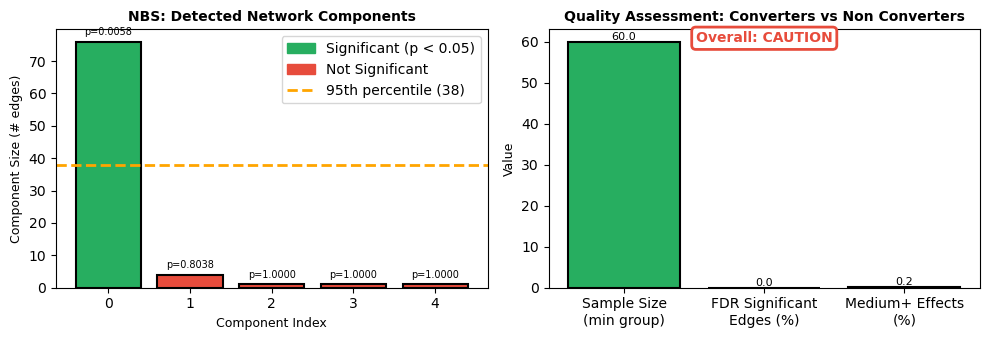

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

sig_comps = nbs['significant_components']
components = nbs['all_components']

if len(components) > 0:
    comp_sizes = [c['size'] for c in components]
    comp_pvals = [c.get('p_value', 1) for c in components]
    colors = ['#27ae60' if p < 0.05 else '#e74c3c' for p in comp_pvals]
    
    x_pos = np.arange(len(comp_sizes))
    bars = axes[0].bar(x_pos, comp_sizes, color=colors, edgecolor='black', linewidth=1.5)
    
    pct_95 = np.percentile(null_dist, 95)
    axes[0].axhline(y=pct_95, color='orange', linestyle='--', linewidth=2, label=f'95th percentile ({pct_95:.0f})')
    
    for i, (bar, p) in enumerate(zip(bars, comp_pvals)):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                     f'p={p:.4f}', ha='center', fontsize=7)
    
    axes[0].set_xlabel('Component Index', fontsize=9)
    axes[0].set_ylabel('Component Size (# edges)', fontsize=9)
    axes[0].set_title('NBS: Detected Network Components', fontsize=10, fontweight='bold')
    axes[0].set_xticks(x_pos)
    axes[0].legend()
    
    sig_patch = mpatches.Patch(color='#27ae60', label='Significant (p < 0.05)')
    nonsig_patch = mpatches.Patch(color='#e74c3c', label='Not Significant')
    axes[0].legend(handles=[sig_patch, nonsig_patch, axes[0].get_legend_handles_labels()[0][-1]], loc='upper right')

n_a = diag_results['n_a']
n_b = diag_results['n_b']
pair_name = diag_results['pair_name']
sig_fdr_pct = diag_results['sig_fdr_pct']

categories = ['Sample Size\n(min group)', 'FDR Significant\nEdges (%)', 'Medium+ Effects\n(%)']
values = [min(n_a, n_b), sig_fdr_pct, diag_results['pct_medium_effect']]
thresholds = [30, 1.0, 1.0]
bar_colors = ['#27ae60' if v >= t else '#f39c12' if v >= t*0.5 else '#e74c3c' 
              for v, t in zip(values, thresholds)]

bars = axes[1].bar(categories, values, color=bar_colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.1f}', ha='center', fontsize=8)

axes[1].set_ylabel('Value', fontsize=9)
axes[1].set_title(f'Quality Assessment: {pair_name}', fontsize=10, fontweight='bold')

min_n = min(n_a, n_b)
if min_n >= 30 and sig_fdr_pct >= 1.0:
    status, status_color = 'GOOD', '#27ae60'
elif min_n >= 20 and sig_fdr_pct >= 0.5:
    status, status_color = 'MODERATE', '#f39c12'
else:
    status, status_color = 'CAUTION', '#e74c3c'

axes[1].text(0.5, 0.95, f'Overall: {status}', transform=axes[1].transAxes, 
             ha='center', fontsize=10, fontweight='bold', color=status_color,
             bbox=dict(boxstyle='round', facecolor='white', edgecolor=status_color, linewidth=2))

plt.tight_layout()
plt.show()

**Interpretation:** Left: Individual network components detected by NBS, with significance indicated by color (green = significant, red = not significant). Right: Quality metrics for the analysis. Small sample sizes or low signal can affect reliability and increase caution.

In [12]:
permanova = results['permanova']
nbs = results['nbs']
diag = diag_results

print(diag_results.keys())

summary = f"""
{'='*60}
       STATISTICAL ANALYSIS SUMMARY
       Converters vs Non-Converters
{'='*60}

SAMPLE SIZES
  • Converters:      n = {diag['n_a']}
  • Non-Converters:  n = {diag['n_b']}
  • Total edges:     {len(diag['pvals'])}

PERMANOVA (Global Group Difference)
  • F-statistic:     {permanova['f_statistic']:.3f}
  • R² (variance):   {permanova['r_squared']*100:.2f}%
  • p-value:         {permanova['p_value']:.4f} {'✓ SIGNIFICANT' if permanova['p_value'] < 0.05 else '✗ NOT SIGNIFICANT'}

NETWORK-BASED STATISTIC (NBS)
  • Threshold:       t = {nbs['primary_threshold']}
  • Suprathreshold:  {np.sum(nbs['suprathreshold_edges'])} edges
  • Components:      {len(nbs['all_components'])} found
  • Significant:     {len(nbs['significant_components'])} component(s)
  • Largest comp:    {nbs['all_components'][0]['size'] if nbs['all_components'] else 0} edges (p = {nbs['all_components'][0]['p_value'] if nbs['all_components'] else 'N/A'})

EDGE-WISE ANALYSIS
  • Sig. uncorrected: {diag['sig_uncorrected']} edges (p < 0.05)
  • Sig. FDR:         {diag['sig_fdr_count']} edges ({diag['sig_fdr_pct']:.2f}%)
  • Median |d|:       {diag['median_effect_size']:.3f}
  • Medium effects:   {diag['pct_medium_effect']:.1f}% of edges

{'='*60}
INTERPRETATION:
  The PERMANOVA shows {'a significant' if permanova['p_value'] < 0.05 else 'no significant'} 
  global difference between groups.
  
  NBS identified {len(nbs['significant_components'])} significant network component(s),
  suggesting {'localized connectivity differences' if nbs['significant_components'] else 'no network-level differences'}.
  
  Effect sizes are generally {'small' if diag['median_effect_size'] < 0.3 else 'moderate'},
  typical for neuroimaging studies.
{'='*60}
"""

print(summary)

dict_keys(['valid', 'pair_name', 'n_a', 'n_b', 'min_sample_size', 'avg_sd_a', 'avg_sd_b', 'sig_uncorrected', 'sig_fdr_count', 'sig_fdr_pct', 'median_effect_size', 'pct_medium_effect', 'pct_large_effect', 'pvals', 'pvals_fdr', 'cohens_d'])

       STATISTICAL ANALYSIS SUMMARY
       Converters vs Non-Converters

SAMPLE SIZES
  • Converters:      n = 60
  • Non-Converters:  n = 533
  • Total edges:     5995

PERMANOVA (Global Group Difference)
  • F-statistic:     1.530
  • R² (variance):   0.26%
  • p-value:         0.0034 ✓ SIGNIFICANT

NETWORK-BASED STATISTIC (NBS)
  • Threshold:       t = 3.0
  • Suprathreshold:  83 edges
  • Components:      5 found
  • Significant:     1 component(s)
  • Largest comp:    76 edges (p = 0.0058)

EDGE-WISE ANALYSIS
  • Sig. uncorrected: 600 edges (p < 0.05)
  • Sig. FDR:         0 edges (0.00%)
  • Median |d|:       0.115
  • Medium effects:   0.2% of edges

INTERPRETATION:
  The PERMANOVA shows a significant 
  global difference between groups.

  NB